In [1]:

import os
import pandas as pd
import anndata as ad
import isabl_cli as ii
import scgenome


os.environ['ISABL_API_URL'] = 'https://isabl.shahlab.mskcc.org/api/v1/'

hmmcopy_analyses = ii.get_instances(
    'analyses',
    application__name='MONDRIAN-QC',
    targets__projects__title='Osteosarcoma',
    targets__sample__individual__identifier='MSKOST_37597',
    status__in=('SUCCEEDED', 'FINISHED'),
)


Retrieving 3 from analyses API endpoint...


In [2]:

hmmcopy_adata = []

for analysis in hmmcopy_analyses:
    reads_filename = analysis['results']['reads']
    metrics_filename = analysis['results']['metrics']

    sample_adata = scgenome.pp.read_dlp_hmmcopy(reads_filename, metrics_filename)

    hmmcopy_adata.append(sample_adata)

hmmcopy_adata = ad.concat(hmmcopy_adata, join='outer', merge='first')

hmmcopy_adata


AnnData object with n_obs × n_vars = 4066 × 6206
    obs: 'MBRSI_dispersion_non_integerness', 'MBRSM_dispersion', 'MSRSI_non_integerness', 'aligned', 'autocorrelation_hmmcopy', 'breakpoints', 'column', 'condition', 'coverage_breadth', 'coverage_depth', 'cv_hmmcopy', 'empty_bins_hmmcopy', 'estimated_library_size', 'expected', 'fastqscreen_grch37', 'fastqscreen_grch37_multihit', 'fastqscreen_mm10', 'fastqscreen_mm10_multihit', 'fastqscreen_nohit', 'fastqscreen_salmon', 'fastqscreen_salmon_multihit', 'fastqscreen_total_reads', 'img_col', 'index_i5', 'index_i7', 'index_sequence', 'is_contaminated', 'is_control', 'library_id', 'log_likelihood', 'mad_hmmcopy', 'mad_neutral_state', 'mean_copy', 'mean_hmmcopy_reads_per_bin', 'mean_insert_size', 'mean_state_mads', 'mean_state_vars', 'median_hmmcopy_reads_per_bin', 'median_insert_size', 'multiplier', 'overlap_with_all_filters', 'overlap_with_all_filters_and_qual', 'overlap_with_dups', 'overlap_without_dups', 'paired_duplicate_reads', 'paired_map

/Users/mcphera1/Projects/dlp_tutorial/venv/src/scgenome/scgenome/tools/sorting.py:201: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['cell_order'] = np.nan


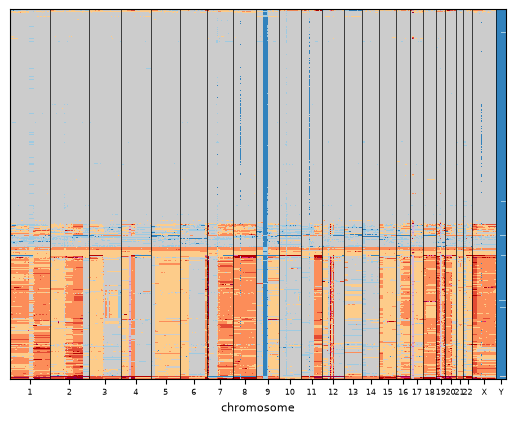

In [3]:

hmmcopy_adata = hmmcopy_adata[
    (hmmcopy_adata.obs['quality'] > 0.75) &
    (hmmcopy_adata.obs['is_control'] == False)
]

hmmcopy_adata = scgenome.tl.sort_cells(hmmcopy_adata, layer_name='copy')

g = scgenome.pl.plot_cell_tcn_matrix(
    hmmcopy_adata,
    layer_name='state',
    cell_order_fields=['cell_order'],
)

In [4]:

signals_analyses = ii.get_instances(
    'analyses',
    application__name='SIGNALS',
    targets__projects__title='Osteosarcoma',
    targets__sample__individual__identifier='MSKOST_37597',
    status__in=('SUCCEEDED', 'FINISHED'),
)

signals_analysis = signals_analyses[0]

hscn_filename = signals_analysis['results']['hscn']

signals_adata = scgenome.pp.read_dlp_signals(hscn_filename)

signals_adata


Retrieving 1 from analyses API endpoint...


AnnData object with n_obs × n_vars = 580 × 6087
    var: 'chr', 'start', 'end'
    layers: 'totalcounts', 'alleleA', 'alleleB', 'BAF', 'A', 'B'

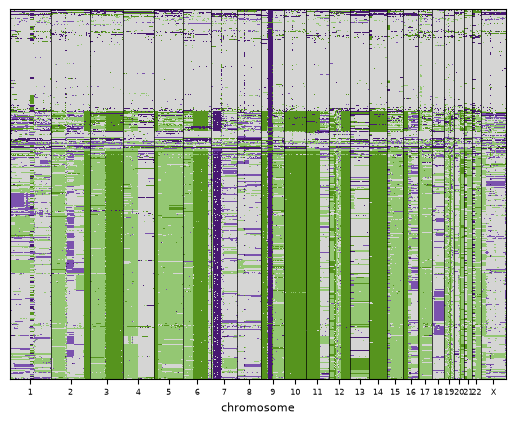

In [5]:

signals_adata = scgenome.tl.sort_cells(signals_adata, layer_name=['A', 'B'])

g = scgenome.pl.plot_cell_ascn_matrix(
    signals_adata,
    cell_order_fields=['cell_order'],
)


In [28]:

snvgenotyping_analyses = ii.get_instances(
    'analyses',
    application__name='MONDRIAN-SNVGENOTYPING',
    targets__projects__title='Osteosarcoma',
    targets__sample__individual__identifier='MSKOST_37597',
    status__in=('SUCCEEDED', 'FINISHED'),
)

snv_adata = []

for analysis in snvgenotyping_analyses:
    vartrix_filename = analysis['results']['vartrix']

    sample_adata = scgenome.pp.read_snv_genotyping(vartrix_filename)

    snv_adata.append(sample_adata)

snv_adata = ad.concat(snv_adata, join='outer', merge='first')

snv_adata


Retrieving 3 from analyses API endpoint...


AnnData object with n_obs × n_vars = 3466 × 1017356
    var: 'chromosome', 'position', 'ref', 'alt'
    layers: 'alt_count', 'ref_count'

In [ ]:

articul_analyses = ii.get_instances(
    'analyses',
    application__name='ARTICULL',
    targets__projects__title='Osteosarcoma',
    targets__sample__individual__identifier='MSKOST_37597',
    status__in=('SUCCEEDED', 'FINISHED'),
)

articul_data = []
for analysis in articul_analyses:
    result_filename = analysis['results']['result']
    articul_data.append(pd.read_csv(result_filename, sep='\t', dtype={'chrm': str}, low_memory=False))
articul_data = pd.concat(articul_data, ignore_index=True)

articul_data['snv_id'] = (
    articul_data['chrm'].astype(str) + '-' +
    articul_data['pos'].astype(str) + ':' +
    articul_data['ref_allele'] + '>' +
    articul_data['alt_allele']
)

articul_data.head()


Retrieving 3 from analyses API endpoint...


,chrm,pos,ref_allele,alt_allele,result,prob_artifact,snv_id
0,1,963705,C,A,PASS,0.452383,1-963705:C>A
1,1,967895,G,T,ARTIFACT,0.955605,1-967895:G>T
2,1,1027523,G,A,PASS,0.034340,1-1027523:G>A
3,1,1037686,G,C,ARTIFACT,0.990393,1-1037686:G>C
4,1,1416358,G,T,ARTIFACT,0.989622,1-1416358:G>T


In [29]:

# Filter snv_adata to only include passed by articul
snv_adata = snv_adata[:, snv_adata.var.index.isin(articul_data.query('result == "PASS"')['snv_id'])]
snv_adata


View of AnnData object with n_obs × n_vars = 3466 × 10757
    var: 'chromosome', 'position', 'ref', 'alt'
    layers: 'alt_count', 'ref_count'

In [30]:

sbmclone_analyses = ii.get_instances(
    'analyses',
    application__name='SBMCLONE',
    targets__projects__title='Osteosarcoma',
    targets__sample__individual__identifier='MSKOST_37597',
    status__in=('SUCCEEDED', 'FINISHED'),
)

sbmclone_analysis = sbmclone_analyses[0]

snvs = pd.read_csv(sbmclone_analysis['results']['snvs'], dtype={'chromosome': str}, low_memory=False)
cells = pd.read_csv(sbmclone_analysis['results']['cells'], low_memory=False)

display(snvs.head())
display(cells.head())


Retrieving 1 from analyses API endpoint...


,chromosome,position,ref,alt,snv_id,block_assignment,mean_cell_block_ari,mean_snv_block_ari
0,1,100236341,A,G,1-100236341:A>G,0,0.884233,0.926142
1,1,100285524,A,T,1-100285524:A>T,2,0.884233,0.926142
2,1,10035445,G,A,1-10035445:G>A,0,0.884233,0.926142
3,1,100686533,G,A,1-100686533:G>A,0,0.884233,0.926142
4,1,101022444,A,G,1-101022444:A>G,0,0.884233,0.926142


,cell_id,block_assignment,mean_cell_block_ari,mean_snv_block_ari
0,159827C-R13-C12,3,0.884233,0.926142
1,159827C-R13-C13,3,0.884233,0.926142
2,159827C-R13-C14,4,0.884233,0.926142
3,159827C-R13-C15,4,0.884233,0.926142
4,159827C-R13-C16,3,0.884233,0.926142


In [ ]:

# Filter for cells and SNVs that were used by sbmclone
snv_adata = snv_adata[
    snv_adata.obs.index.isin(cells['cell_id'].values),
    snv_adata.var.index.isin(snvs['snv_id'].values)]

snv_adata.var['block_assignment'] = snvs.set_index('snv_id').loc[snv_adata.var.index, 'block_assignment']
snv_adata.var['mean_cell_block_ari'] = snvs.set_index('snv_id').loc[snv_adata.var.index, 'mean_cell_block_ari']
snv_adata.var['mean_snv_block_ari'] = snvs.set_index('snv_id').loc[snv_adata.var.index, 'mean_snv_block_ari']

snv_adata.obs['block_assignment'] = cells.set_index('cell_id').loc[snv_adata.obs.index, 'block_assignment']
snv_adata.obs['mean_cell_block_ari'] = cells.set_index('cell_id').loc[snv_adata.obs.index, 'mean_cell_block_ari']
snv_adata.obs['mean_snv_block_ari'] = cells.set_index('cell_id').loc[snv_adata.obs.index, 'mean_snv_block_ari']

snv_adata

,block_assignment,mean_cell_block_ari,mean_snv_block_ari
cell_id,,,
159980C-R17-C53,4,0.884233,0.926142
159980C-R16-C12,0,0.884233,0.926142
159980C-R18-C31,1,0.884233,0.926142
159980C-R15-C30,4,0.884233,0.926142
159980C-R45-C18,1,0.884233,0.926142
...,...,...,...
160023C-R26-C20,5,0.884233,0.926142
160023C-R21-C22,5,0.884233,0.926142
160023C-R13-C24,5,0.884233,0.926142
